✅ Seed установлен: 42
Целевая переменная: float64
Уникальных значений: 566
Определен тип задачи: regression

📊 Разделение данных:
   Обучающая выборка (train): 7989 samples (60.0%)
   Валидационная выборка (val): 2663 samples (20.0%)
   Тестовая выборка (test): 2664 samples (20.0%)
✅ Признаки были масштабированы (целевая переменная без изменений).


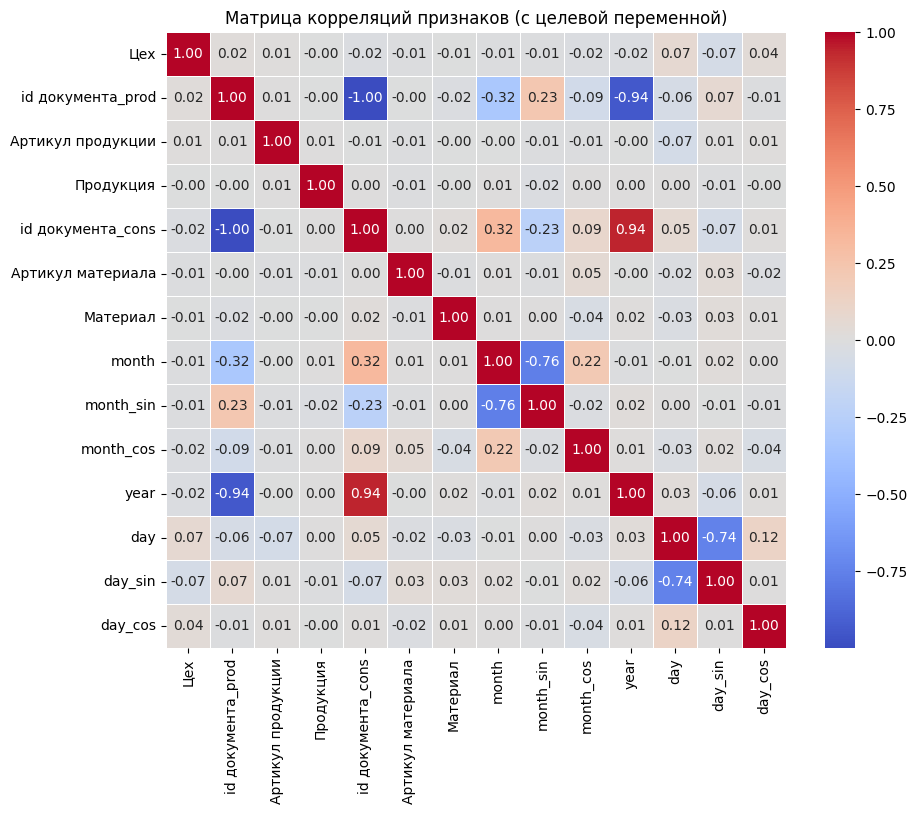


🧠 ОБУЧЕНИЕ НЕЙРОСЕТИ MLP
Epoch  100 | Train: 566.6362 | Val: 536.7881
Epoch  200 | Train: 549.3513 | Val: 524.1442
Epoch  300 | Train: 546.0156 | Val: 522.0668
Epoch  400 | Train: 543.1144 | Val: 520.0987
Epoch  500 | Train: 534.9484 | Val: 514.3013
Epoch  600 | Train: 518.2736 | Val: 500.9861
Epoch  700 | Train: 495.5202 | Val: 483.9566
Epoch  800 | Train: 468.4643 | Val: 463.2621
Epoch  900 | Train: 437.5515 | Val: 439.6465


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import time
import torch
import random
import os
import torch.nn as nn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim  # ✅ Добавить эту строку!
from torch.utils.data import DataLoader

# Подавление предупреждений
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning, module='optuna')
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

# --- Импорты для моделей ---
# Классификаторы
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier

# Регрессоры
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# --- Импорты для метрик ---
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# --- Бустинговые модели ---
try:
    from xgboost import XGBClassifier, XGBRegressor
    from lightgbm import LGBMClassifier, LGBMRegressor
    from catboost import CatBoostClassifier, CatBoostRegressor
    _BOOSTING_INSTALLED = True
except ImportError:
    _BOOSTING_INSTALLED = False
    print("⚠️ Бустинговые модели не установлены. pip install xgboost lightgbm catboost")


# ============================================================================
# КЛАСС Dataset
# ============================================================================
class Dataset:
    """
    Класс для загрузки, анализа и предобработки данных.
    Автоматически определяет тип задачи (классификация/регрессия).
    ✅ ИСПРАВЛЕНО: Теперь разделяет на train/validation/test (3 выборки)
    """

    def __init__(self, data_source, target_column, task_type=None, 
                 test_size=0.2, val_size=0.2, random_state=42, 
                 categorical_columns=None, one_hot_encoding=False):
        if isinstance(data_source, str):
            self.df = pd.read_csv(data_source)
        elif isinstance(data_source, pd.DataFrame):
            self.df = data_source
        else:
            raise ValueError("data_source должен быть путем к файлу или pandas DataFrame")

        self.target_column = target_column
        self.X = self.df.drop(columns=[self.target_column])
        self.y = self.df[self.target_column]

        self.task_type = task_type or self._infer_task_type()
        print(f"Определен тип задачи: {self.task_type}")

        if one_hot_encoding:
            self.one_hot_encoding(categorical_columns)
        
        # ✅ ИСПРАВЛЕНО: Разделение на 3 выборки (train/val/test)
        # Сначала отделяем тестовую выборку
        stratify = self.y if self.task_type == 'classification' and self.y.nunique() > 1 else None
        
        # test_size от общего объема данных
        self.X_train_val, self.X_test, self.y_train_val, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state, stratify=stratify
        )
        
        # val_size от оставшихся данных (train_val)
        val_ratio = val_size / (1 - test_size)  # Конвертируем в долю от train_val
        stratify_train_val = self.y_train_val if self.task_type == 'classification' and self.y_train_val.nunique() > 1 else None
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            self.X_train_val, self.y_train_val, 
            test_size=val_ratio, 
            random_state=random_state, 
            stratify=stratify_train_val
        )
        
        print(f"\n📊 Разделение данных:")
        print(f"   Обучающая выборка (train): {len(self.X_train)} samples ({len(self.X_train)/len(self.X)*100:.1f}%)")
        print(f"   Валидационная выборка (val): {len(self.X_val)} samples ({len(self.X_val)/len(self.X)*100:.1f}%)")
        print(f"   Тестовая выборка (test): {len(self.X_test)} samples ({len(self.X_test)/len(self.X)*100:.1f}%)")
        
        self.scaler = None

    def _infer_task_type(self):
        """Автоматически определяет тип задачи на основе целевой переменной."""
        if pd.api.types.is_float_dtype(self.y):
            return 'regression'
        if self.y.nunique() < 30 and self.y.nunique() / len(self.y) < 0.2:
            return 'classification'
        return 'regression'

    def scale_features(self, scale_target=False):
        """Масштабирует признаки с помощью StandardScaler."""
        self.scaler = StandardScaler()
        self.X_train = pd.DataFrame(self.scaler.fit_transform(self.X_train), columns=self.X.columns)
        self.X_val = pd.DataFrame(self.scaler.transform(self.X_val), columns=self.X.columns)
        self.X_test = pd.DataFrame(self.scaler.transform(self.X_test), columns=self.X.columns)
    
        # ⚠️ Для регрессии y обычно не масштабируют (только для нейросетей иногда)
        if scale_target and self.task_type == 'regression':
            self.y_scaler = StandardScaler()
            self.y_train = self.y_scaler.fit_transform(self.y_train.values.reshape(-1, 1)).flatten()
            self.y_val = self.y_scaler.transform(self.y_val.values.reshape(-1, 1)).flatten()
            self.y_test = self.y_scaler.transform(self.y_test.values.reshape(-1, 1)).flatten()
            print("✅ Признаки и целевая переменная были масштабированы.")
        else:
            # ✅ Просто конвертируем в numpy array для совместимости
            self.y_train = self.y_train.values
            self.y_val = self.y_val.values
            self.y_test = self.y_test.values
            print("✅ Признаки были масштабированы (целевая переменная без изменений).")

    def plot_correlation_matrix(self, include_target=True, figsize=(10, 8), annot=True, cmap='coolwarm'):
        """Строит и отображает матрицу корреляций для признаков."""
        if include_target:
            df_for_corr = self.df.copy()
            if self.task_type == 'classification' and not pd.api.types.is_numeric_dtype(df_for_corr[self.target_column]):
                warnings.warn("Целевая переменная является категориальной.")
        else:
            df_for_corr = self.X.copy()
            
        correlation_matrix = df_for_corr.corr()

        plt.figure(figsize=figsize)
        sns.heatmap(correlation_matrix, annot=annot, cmap=cmap, fmt=".2f", linewidths=.5)
        plt.title('Матрица корреляций признаков' + (' (с целевой переменной)' if include_target else ''))
        plt.show()

    def one_hot_encoding(self, categorical_columns):
        df = self.X.copy()
    
        if categorical_columns is None:
            categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
        df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=False)
    
        self.X = df_encoded

    def X_count(self):
        return len(self.X.columns)

    def to_tensors(self, device='cpu'):
        """Конвертирует данные в torch.Tensor"""
        return {
            'X_train': torch.FloatTensor(self.X_train.values).to(device),
            'y_train': torch.FloatTensor(self.y_train.values).view(-1, 1).to(device),
            'X_val': torch.FloatTensor(self.X_val.values).to(device),
            'y_val': torch.FloatTensor(self.y_val.values).view(-1, 1).to(device),
            'X_test': torch.FloatTensor(self.X_test.values).to(device),
            'y_test': torch.FloatTensor(self.y_test.values).view(-1, 1).to(device),
        }


# ============================================================================
# КЛАСС ModelFactory
# ============================================================================
class ModelFactory:
    """Фабрика для создания моделей в зависимости от типа задачи."""
    _classification_models = {
        "knn": KNeighborsClassifier, 
        "svm": SVC, 
        "naive_bayes": GaussianNB,
        "logistic_regression": LogisticRegression, 
        "random_forest": RandomForestClassifier,
        "ridge_classifier": RidgeClassifier
    }
    _regression_models = {
        "linear_regression": LinearRegression, 
        "ridge": Ridge, 
        "lasso": Lasso,
        "knn": KNeighborsRegressor, 
        "svm": SVR, 
        "random_forest": RandomForestRegressor,
    }

    if _BOOSTING_INSTALLED:
        _classification_models.update({
            "xgboost": XGBClassifier, 
            "lightgbm": LGBMClassifier, 
            "catboost": CatBoostClassifier,
        })
        _regression_models.update({
            "xgboost": XGBRegressor, 
            "lightgbm": LGBMRegressor, 
            "catboost": CatBoostRegressor,
        })

    @staticmethod
    def get_model(model_name, task_type, params=None):
        models_dict = ModelFactory._regression_models if task_type == 'regression' else ModelFactory._classification_models
        
        if model_name not in models_dict:
            if model_name in ["xgboost", "lightgbm", "catboost"]:
                raise ValueError(f"Модель '{model_name}' не установлена.")
            raise ValueError(f"Модель '{model_name}' не поддерживается для задачи '{task_type}'.")
        
        model_class = models_dict[model_name]
        params = params.copy() if params else {}
        
        if task_type == 'classification' and model_name == 'svm' and params.get('probability') is None:
            params['probability'] = True

        if model_name == "random_forest" and "learning_rate" in params:
            del params["learning_rate"]
            
        return model_class(**params)


# ============================================================================
# КЛАСС MetaModel
# ============================================================================
class MetaModel:
    """Мета-класс с поддержкой GPU для совместимых моделей."""
    
    def __init__(self, dataset: Dataset, model_name: str, model_params="optuna", use_gpu=True):
        self.dataset = dataset
        self.model_name = model_name
        self.model_params = model_params
        self.task_type = dataset.task_type
        self.model = None
        self.best_params_ = None
        self.use_gpu = use_gpu and torch.cuda.is_available()
        
        if self.use_gpu:
            print(f"🚀 Используется GPU: {torch.cuda.get_device_name(0)}")
        else:
            print("💻 Используется CPU")

    def _get_gpu_params(self, params):
        """Добавляет GPU параметры для соответствующих моделей."""
        if not self.use_gpu:
            return params
        
        params = params.copy()
            
        if self.model_name == 'xgboost':
            params['device'] = 'cuda:0'
            params['tree_method'] = 'hist'
            
        elif self.model_name == 'lightgbm':
            params['device'] = 'gpu'
            params['gpu_platform_id'] = 0
            params['gpu_device_id'] = 0
            
        elif self.model_name == 'catboost':
            params['task_type'] = 'GPU'
            params['devices'] = '0'
        
        return params

    def _objective(self, trial):
        """
        Целевая функция для Optuna.
        ✅ ИСПРАВЛЕНО: Теперь использует validation выборку, а не test!
        """
        is_classification = self.task_type == 'classification'
        
        # ✅ XGBoost
        if self.model_name == 'xgboost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            }
            params = self._get_gpu_params(params)
            
        # ✅ LightGBM
        elif self.model_name == 'lightgbm':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'num_leaves': trial.suggest_int('num_leaves', 20, 300),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'verbose': -1,
            }
            params = self._get_gpu_params(params)
            
        # ✅ CatBoost
        elif self.model_name == 'catboost':
            params = {
                'iterations': trial.suggest_int('iterations', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'depth': trial.suggest_int('depth', 4, 10),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 30),
                'verbose': 0,
            }
            params = self._get_gpu_params(params)
            
        # ✅ Random Forest
        elif self.model_name == 'random_forest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            }
            
        # ✅ KNN
        elif self.model_name == 'knn':
            params = {
                'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
                'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
                'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean']),
                'p': trial.suggest_int('p', 1, 3),
            }
            
        # ✅ SVM
        elif self.model_name == 'svm':
            C = trial.suggest_float("C", 1e-3, 1e3, log=True)
            kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
            if kernel in ["rbf", "poly"]:
                gamma = trial.suggest_float("gamma", 1e-4, 1e-1, log=True)
            else:
                gamma = "scale"
            params = {"C": C, "kernel": kernel, "gamma": gamma}
            if is_classification:
                params["probability"] = True
                
        # ✅ Остальные модели
        else:
            params = {}

        model = ModelFactory.get_model(self.model_name, self.task_type, params)
        
        start_time = time.time()
        # ✅ Обучаем на train, оцениваем на validation (не test!)
        model.fit(self.dataset.X_train, self.dataset.y_train)
        train_time = time.time() - start_time
        
        # ✅ ИСПРАВЛЕНО: Оценка на validation выборке
        y_pred = model.predict(self.dataset.X_val)

        if is_classification:
            score = f1_score(self.dataset.y_val, y_pred, average='macro')
        else:
            score = -mean_squared_error(self.dataset.y_val, y_pred)
        
        trial.set_user_attr("train_time", train_time)
        
        return score

    def train(self, n_trials=50):
        print(f"\n{'='*60}")
        print(f"🚀 Обучение модели: {self.model_name} для задачи {self.task_type}")
        print(f"{'='*60}")
        
        if self.model_params == "optuna":
            direction = "maximize"
            print(f"🔍 Запуск Optuna ({n_trials} итераций)...")

            study = optuna.create_study(direction=direction)
            study.optimize(self._objective, n_trials=n_trials, show_progress_bar=True)
            
            self.best_params_ = study.best_params
            print(f"\n✅ Лучшие гиперпараметры найдены:")
            for param, value in self.best_params_.items():
                print(f"   {param}: {value}")
            
            best_trial = study.best_trial
            if "train_time" in best_trial.user_attrs:
                print(f"   ⏱️ Время обучения лучшего trials: {best_trial.user_attrs['train_time']:.2f} сек")
            
            best_params_with_gpu = self._get_gpu_params(self.best_params_.copy())
            self.model = ModelFactory.get_model(self.model_name, self.task_type, best_params_with_gpu)
        else:
            print("📋 Использование заданных гиперпараметров")
            params_with_gpu = self._get_gpu_params(self.model_params.copy() if self.model_params else {})
            self.model = ModelFactory.get_model(self.model_name, self.task_type, params_with_gpu)

        # ✅ Финальное обучение на train + val вместе (или только на train)
        start_time = time.time()
        self.model.fit(self.dataset.X_train, self.dataset.y_train)
        train_time = time.time() - start_time
        
        print(f"✅ Модель успешно обучена за {train_time:.2f} сек")
        
        if self.use_gpu and self.model_name in ['xgboost', 'lightgbm', 'catboost']:
            print(f"🎮 Обучение происходило на GPU")

    def evaluate(self):
        """
        ✅ ИСПРАВЛЕНО: Оценка только на тестовой выборке (финальная)
        """
        if self.model is None:
            raise RuntimeError("Модель не обучена. Вызовите метод train() перед оценкой.")
        
        print(f"\n--- Оценка модели {self.model_name} на TEST выборке ---")
        y_pred = self.model.predict(self.dataset.X_test)
        
        if self.task_type == 'classification':
            print("Отчет по классификации на тестовой выборке:")
            print(classification_report(self.dataset.y_test, y_pred))
            accuracy = accuracy_score(self.dataset.y_test, y_pred)
            f1 = f1_score(self.dataset.y_test, y_pred, average='macro')
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  Macro F1-Score: {f1:.4f}")
            return (accuracy, f1)
        else:
            print("Метрики регрессии на тестовой выборке:")
            r2 = r2_score(self.dataset.y_test, y_pred)
            mse = mean_squared_error(self.dataset.y_test, y_pred) 
            mae = mean_absolute_error(self.dataset.y_test, y_pred)
            print(f"  R² (коэффициент детерминации): {r2:.4f}")
            print(f"  MSE (среднеквадратичная ошибка): {mse:.4f}")
            print(f"  MAE (средняя абсолютная ошибка): {mae:.4f}")
            return (r2, mse, mae)


# ============================================================================
# НЕЙРОСЕТЬ MLP
# ============================================================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.network(x)


def set_seed(seed=42):
    """Фиксирует все генераторы случайных чисел"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Seed установлен: {seed}")


def evaluate_pytorch_model(model, X_test, y_test, task_type='regression'):
    """Вычисляет метрики для PyTorch модели"""
    model.eval()
    with torch.no_grad():
        if isinstance(X_test, pd.DataFrame):
            X_test = torch.FloatTensor(X_test.values)
        if isinstance(y_test, pd.Series):
            y_test = torch.FloatTensor(y_test.values).view(-1, 1)
        
        predictions = model(X_test)
        y_pred = predictions.numpy().flatten()
        y_true = y_test.flatten()
        
        if task_type == 'regression':
            r2 = r2_score(y_true, y_pred)
            mse = mean_squared_error(y_true, y_pred)
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mse)
            
            print(f"\n🧠 Метрики нейросети (регрессия):")
            print(f"  R²:  {r2:.4f}")
            print(f"  MSE: {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE: {mae:.4f}")
            return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}
        else:
            acc = accuracy_score(y_true, y_pred.round())
            f1 = f1_score(y_true, y_pred.round(), average='macro')
            print(f"\n🧠 Метрики нейросети (классификация):")
            print(f"  Accuracy: {acc:.4f}")
            print(f"  Macro F1: {f1:.4f}")
            return {'accuracy': acc, 'f1': f1}


# ============================================================================
# 🚀 ОСНОВНОЙ КОД
# ============================================================================
if __name__ == "__main__":
    set_seed(42)
    
    # Загрузка данных
    df = pd.read_csv("kalashnikov_task1/clear.csv")

    # Проверка данных
    print(f"Целевая переменная: {df['Материал'].dtype}")
    print(f"Уникальных значений: {df['Материал'].nunique()}")

    # ✅ Создание датасета с 3 выборками (train/val/test)
    dataset = Dataset(
        df, 
        "Материал", 
        task_type="regression", 
        test_size=0.2,      # 20% на тест
        val_size=0.2,       # 20% от оставшихся на валидацию (~16% от общего)
        random_state=42, 
        categorical_columns=["Цех"], 
        one_hot_encoding=True
    )
    dataset.scale_features()
    dataset.plot_correlation_matrix()

    # Модели для тестирования
    models = []#["catboost", "lightgbm", "xgboost",] #"random_forest", "knn"]
    results = {}

    for m in models:
        print(f"\n{'='*60}")
        print(f"Модель: {m}")
        print(f"{'='*60}")
        
        use_gpu = (m in ['catboost', 'lightgbm', 'xgboost'])
        
        model = MetaModel(dataset, m, model_params="optuna", use_gpu=use_gpu)
        model.train(n_trials=50)  # 50 итераций Optuna
        metrics = model.evaluate()  # ✅ Оценка на TEST (не val!)
        results[m] = metrics[0]  # R² для регрессии

    # ============================================================================
    # 🧠 ОБУЧЕНИЕ НЕЙРОСЕТИ С VALIDATION
    # ============================================================================
    print("\n" + "="*60)
    print("🧠 ОБУЧЕНИЕ НЕЙРОСЕТИ MLP")
    print("="*60)
    
    # ✅ Используем validation для early stopping
    X_train = torch.FloatTensor(dataset.X_train.values)
    y_train = torch.FloatTensor(dataset.y_train).view(-1, 1)
    X_val = torch.FloatTensor(dataset.X_val.values)
    y_val = torch.FloatTensor(dataset.y_val).view(-1, 1)
    X_test = torch.FloatTensor(dataset.X_test.values)
    y_test = torch.FloatTensor(dataset.y_test).view(-1, 1)

    mlp_model = MLP(dataset.X_count())
    criterion = nn.HuberLoss(delta=10.0)
    optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

    loss_history = []
    val_loss_history = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    mlp_model.train()
    for epoch in range(5000):  
        optimizer.zero_grad()
        outputs = mlp_model(X_train)
        train_loss = criterion(outputs, y_train)
        loss_history.append(train_loss.item())
        train_loss.backward()
        optimizer.step()
        
        # ✅ Валидация каждую 5-ю эпоху
        if epoch % 5 == 0:
            mlp_model.eval()
            with torch.no_grad():
                val_outputs = mlp_model(X_val)  # ✅ На validation, не test!
                val_loss = criterion(val_outputs, y_val)
            val_loss_history.append(val_loss.item())
            mlp_model.train()
            
            scheduler.step(val_loss)
            
            # ✅ Early stopping по validation loss
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_model_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= 100:
                    print(f"⏹️ Early stopping на эпохе {epoch}")
                    break
        
        if (epoch + 1) % 100 == 0:
            print(f'Epoch {epoch+1:4d} | Train: {train_loss.item():.4f} | Val: {val_loss.item():.4f}')

    # ✅ Загружаем лучшие веса
    if best_model_state is not None:
        mlp_model.load_state_dict(best_model_state)
        print("✅ Загружены веса с лучшим validation loss")

    # ✅ Оценка нейросети на TEST выборке
    print("\n" + "="*60)
    print("🧠 ОЦЕНКА НЕЙРОСЕТИ MLP НА TEST ВЫБОРКЕ")
    print("="*60)
    mlp_metrics = evaluate_pytorch_model(mlp_model, dataset.X_test, dataset.y_test, task_type='regression')

    # ============================================================================
    # 📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ
    # ============================================================================
    print("\n" + "="*60)
    print("🏆 ИТОГОВЫЕ РЕЗУЛЬТАТЫ (на TEST выборке)")
    print("="*60)
    
    results['mlp'] = mlp_metrics['r2']
    for model_name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
        marker = "🏆" if model_name == max(results, key=results.get) else " "
        print(f"{marker} {model_name:15s}: R² = {score:.4f}")

    best_model = max(results, key=results.get)
    print(f"\n🏆 Лучшая модель: {best_model}")

    # График потерь
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(loss_history, label='Train Loss', color='blue', linewidth=1, alpha=0.7)
    plt.xlabel('Эпоха', fontsize=12)
    plt.ylabel('Loss', fontsize=12) 
    plt.title('Динамика ошибки обучения (Train)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(val_loss_history, label='Validation Loss', color='red', linewidth=2)
    plt.xlabel('Эпоха (каждая 5-я)', fontsize=12)
    plt.ylabel('Loss', fontsize=12) 
    plt.title('Динамика ошибки валидации', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()